# $B^\pm \to \pi^\pm\pi^+\pi^-$ — Jax-PWA gen-fit study: **isobar generation, QMI fit** (LHCb Run 1 model)

Copy of `b2pipipi_cpvfit_qmi_toy_pull_study_SqDP.ipynb` in which the toys are **generated with the
isobaric LHCb Run 1 model** (S-wave = `sigma` + `rescattering`) and **fitted with the QMI model**
(same P/D/F waves, S-wave replaced by one quasi-model-independent wave). The question is whether
the QMI fit recovers, knot by knot, the magnitude and phase of the isobaric S-wave for each charge,
and whether the P/D/F-wave parameters stay unbiased when the S-wave is described model-independently.

Because the fit model does not contain the generation model, the "true values" of the QMI knots
are *reference* values: the isobaric S-wave evaluated exactly at the knot masses. Any residual bias
on the knots measures the knot-grid/interpolation approximation of the isobaric S-wave (most
visible around the 1.0 and 1.5 GeV edges of the rescattering window, where the isobaric S-wave is
discontinuous), not a fitter bias.

## Model

P/D/F waves: the LHCb Run 1 isobar model of
[Phys. Rev. D 101, 012006 (2020)](https://arxiv.org/abs/1909.05212), as in the isobar notebook:

| component | lineshape | spin | mass, width [GeV] |
|---|---|---|---|
| `rho770` | Gounaris-Sakurai | 1 | 0.7708, 0.1534 (Table XX) |
| `omega782` | relativistic Breit-Wigner | 1 | 0.78265, 0.00849 |
| `f2_1270` | relativistic Breit-Wigner | 2 | 1.256, 0.1867 |
| `rho1450` | relativistic Breit-Wigner | 1 | 1.465, 0.400 |
| `rho3_1690` | relativistic Breit-Wigner | 3 | 1.686, 0.186 |
| `S_QMI` | `QMI`, Cartesian, linear in $s = m^2$ | 0 | 20 knots in $m(\pi^+\pi^-)$ |

All components use `pair=(2, 0)` (symmetrized over the two identical pions), Zemach angular
factors and Blatt-Weisskopf radii of 4.0 GeV⁻¹. Coefficients are
$c_q = (x + q\,\delta x) + i\,(y + q\,\delta y)$, with `rho770.x = 1`, `rho770.y = 0`,
`rho770.dy = 0` fixed as the reference.

**QMI S-wave.** Every knot $k$ carries its own CP-violating Cartesian node,
$A_S^q(m_k) = (x_k + q\,\delta x_k) + i\,(y_k + q\,\delta y_k)$ (`CPRealImag` per knot, all
four parameters free). The component coefficient is fixed to $1 + 0i$ and the component is not
unit-normalized (`normalize_component=False`), so the knots carry the physical S-wave amplitude
and its charge asymmetry; the overall scale and phase come from the fixed `rho770` reference.

**True values of the knots** are the isobaric S-wave of the LHCb model sampled at the knot
masses, separately for each charge, in the normalization convention of the isobar `DecayModel`:
$A_S^q(m_k) = \sum_{j \in \{\sigma,\,\text{resc.}\}} c_j^q\,N_j\,A_j(m_k)$ (Table XXI coefficients,
unit-normalized components). The knot grid has close pairs around the edges of the
1.0–1.5 GeV rescattering window, where the isobaric S-wave is discontinuous.

## Generation and fit

- **Pure signal**, generator level: no efficiency, no background, no veto.
- Toys are generated from the **isobar** model (`sigma` + `rescattering` S-wave, Table XXI
  coefficients) with `generate_cp_toy(..., method="accept-reject")`.
  The B+/B- split of each toy follows the model's integrated charge asymmetry.
- Each toy is fitted with the **QMI** model through `CPFitSession` (joint B+/B- normalization),
  starting from the reference values, with HESSE uncertainties.
- For every knot and charge the per-charge S-wave amplitude
  $A_S^q(m_k) = (x_k + q\,\delta x_k) + i\,(y_k + q\,\delta y_k)$ is converted to magnitude and
  phase, with HESSE errors propagated from the fit covariance, and stored with the fit results.
- Toys are **not** stored. Seeds are deterministic per toy (`SeedSequence([TOY_BASE_SEED, iexpt])`).

## Local caching

Everything lives in `CACHE_DIR` (`notebooks/validation/.cache/`, git-ignored):

1. the persistent JAX compilation cache, so a restarted kernel reuses the compiled toy
   generator. The NLL, gradient and Hessian programs embed each toy's events and can never be
   reused, so the loop deletes every cache entry a toy writes (other than the generator
   programs) and calls `jax.clear_caches()` after each toy to keep disk and RAM flat;
2. `RESULTS_CSV`, written after every toy. Toys already in the CSV are skipped, so the fit loop can
   be interrupted and resumed without losing work.

In [1]:
import os
from pathlib import Path

os.environ["JAX_PLATFORMS"] = "cuda"  # cpu, cuda, tpu
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

# Local cache root; set before JAX is imported so the persistent compilation cache is active
# from the first compiled program.
CACHE_DIR = Path(".cache/b2pipipi_lhcb_run1_isobar_gen_qmi_fit").resolve()
CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("JAX_COMPILATION_CACHE_DIR", str(CACHE_DIR / "jax_compilation"))
os.environ.setdefault("JAX_PERSISTENT_CACHE_MIN_COMPILE_TIME_SECS", "1.0")

'1.0'

In [2]:
import sys

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "src" / "jaxpwa").is_dir():
        sys.path.insert(0, str(candidate / "src"))
        break

import time

import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

from jaxpwa import (
    CPFitSession,
    CPRealImag,
    DecayChannel,
    DecayModel,
    GounarisSakurai,
    Parameter,
    PipiKKRescattering,
    QMI,
    RealImag,
    RelativisticBreitWigner,
    Resonance,
    SigmaPole,
    ZemachP,
    enable_x64,
    generate_cp_toy,
)

from jaxpwa.dynamics.context import resolve_value

enable_x64()

## Configuration

In [3]:
N_TOY_EVENTS = 50_000  # events per toy, B+ and B- together
N_EXPERIMENTS = 500
TOY_INDICES = range(N_EXPERIMENTS)  # narrow this (e.g. range(3)) for a quick smoke test
TOY_BASE_SEED = 1909052120  # toy iexpt uses SeedSequence([TOY_BASE_SEED, iexpt])
TOY_POOL_SIZE = 1_000_000  # accept-reject pilot; large enough to resolve omega(782)

NORMALIZATION_RESOLUTION = 1000  # Square-Dalitz (0, 1) quadrature, as in the benchmark notebook
FIT_STRATEGY = 1
FIT_NCALL = 100_000

QMI_INTERPOLATION = "linear"  # LHCb convention; see docs/lineshapes.md for the other modes

RESULTS_CSV = CACHE_DIR / (
    f"results_isogen_qmifit_{QMI_INTERPOLATION}_n{N_TOY_EVENTS}_seed{TOY_BASE_SEED}"
    f"_res{NORMALIZATION_RESOLUTION}.csv"
)
print(f"results: {RESULTS_CSV}")

results: /data1000/juan/work/AnalisesEmAndamento/Run2/BKKK_Analysis/Jax-PWA/notebooks/validation/.cache/b2pipipi_lhcb_run1_isobar_gen_qmi_fit/results_isogen_qmifit_linear_n50000_seed1909052120_res1000.csv


## Models: isobar (generation) and QMI (fit)

The isobar model (masses/widths and Table XXI coefficients `(x, y, dx, dy)`) is built once per
charge with plain numeric coefficients: it is the **generation model**, and it is also sampled at
the QMI knots to get the reference S-wave $A_S^q(m_k) = \sum_{j \in \{\sigma,\,\text{resc.}\}} c_j^q\,N_j\,A_j(m_k)$.

The **fit model** keeps the same P/D/F waves (each unit-normalized on its own, so their
coefficients are directly comparable with Table XXI) and replaces the S-wave by the QMI. The QMI
node of knot $k$ starts at the CP average and half difference of the two charges,
$x_k + i y_k = (A_S^+ + A_S^-)/2$ and $\delta x_k + i\,\delta y_k = (A_S^+ - A_S^-)/2$; these are
the reference values for the pulls and the starting point of every fit. The first and last knots
sit at the kinematic limits of $m(\pi^+\pi^-)$.

In [4]:
MASS_WIDTHS = {
    "rho770": (0.7708, 0.1534),      # isobar fit, Table XX
    "omega782": (0.78265, 0.00849),  # Laura++/PDG
    "f2_1270": (1.256, 0.1867),      # isobar fit
    "rho1450": (1.465, 0.400),       # Laura++/PDG
    "rho3_1690": (1.686, 0.186),     # Laura++/PDG
    "sigma": (0.563, 0.350),         # fitted pole, Table XXII
}

# name: (x, y, dx, dy), Table XXI
COEFFICIENTS = {
    "rho770": (1.000, 0.000, -0.003, 0.000),
    "omega782": (0.091, -0.007, 0.000, -0.022),
    "f2_1270": (0.291, 0.204, -0.002, -0.179),
    "rho1450": (-0.223, 0.191, 0.031, 0.068),
    "rho3_1690": (0.073, -0.045, 0.044, -0.013),
    "rescattering": (0.142, -0.040, -0.047, -0.027),
    "sigma": (-0.485, 0.284, 0.231, 0.270),
}
S_WAVE_ISOBARS = ("rescattering", "sigma")  # replaced by the QMI in the gen-fit model
FIXED_COEFFICIENTS = {"rho770.x", "rho770.y", "rho770.dy"}  # phase/magnitude reference

LINESHAPES = {
    "rho770": (GounarisSakurai, 1),
    "omega782": (RelativisticBreitWigner, 1),
    "f2_1270": (RelativisticBreitWigner, 2),
    "rho1450": (RelativisticBreitWigner, 1),
    "rho3_1690": (RelativisticBreitWigner, 3),
    "sigma": (SigmaPole, 0),
}

_channel = DecayChannel("B+", ("pi+", "pi+", "pi-"))
M_PI = float(_channel.daughter_masses[0])
M_B = float(_channel.parent_mass)
# m(pi+ pi-) knots [GeV]: kinematic limits at both ends, close pairs around the 1.0-1.5 GeV
# rescattering window edges (where the isobaric S-wave jumps).
QMI_KNOTS = (
    2 * M_PI, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.995, 1.005, 1.10,
    1.20, 1.30, 1.40, 1.495, 1.505, 1.70, 2.00, 3.00, 4.00, M_B - M_PI,
)


def isobar_resonance(name, coefficient):
    if name == "rescattering":
        return Resonance(
            name, (2, 0), coefficient,
            lineshape=PipiKKRescattering(convention="laura", delta_kk_squared=2.8**2),
            mass=1.0, width=0.0, spin=0, resonance_radius=4.0, parent_radius=4.0,
        )
    lineshape, spin = LINESHAPES[name]
    mass, width = MASS_WIDTHS[name]
    return Resonance(
        name, (2, 0), coefficient, lineshape=lineshape(), angular=ZemachP(),
        mass=mass, width=width, spin=spin, resonance_radius=4.0, parent_radius=4.0,
    )


def build_model(charge, components):
    pion, other = ("pi+", "pi-") if charge > 0 else ("pi-", "pi+")
    return DecayModel(
        DecayChannel("B+" if charge > 0 else "B-", (pion, pion, other)),
        components,
        normalize_components=True,
        normalization_method="square-dalitz",
        normalization_pair=(0, 1),
        normalization_resolution=NORMALIZATION_RESOLUTION,
    )


# Generation models: the full isobar model with numeric (non-floating) Table XXI coefficients.
ISOBAR_MODELS = {
    charge: build_model(charge, [
        isobar_resonance(name, CPRealImag(*values).for_charge(charge))
        for name, values in COEFFICIENTS.items()
    ])
    for charge in (+1, -1)
}


def isobar_s_wave(charge, masses):
    """Isobaric S-wave c_j^q N_j A_j(m), summed over sigma and rescattering, at `masses`."""
    model = ISOBAR_MODELS[charge]
    masses = jnp.asarray(masses, dtype=float)
    total = 0.0
    for component in model.amplitude_model.components:
        if component.name not in S_WAVE_ISOBARS:
            continue
        coefficient = complex(np.asarray(component.coefficient.value({})))
        scale = float(np.asarray(model._component_scale(component, {})))
        context = component.function.context.resolve({})
        total = total + coefficient * scale * np.asarray(
            component.function.lineshape(masses, context)
        )
    return total


S_WAVE_KNOTS = {charge: isobar_s_wave(charge, QMI_KNOTS) for charge in (+1, -1)}
s_wave_average = 0.5 * (S_WAVE_KNOTS[+1] + S_WAVE_KNOTS[-1])
s_wave_half_difference = 0.5 * (S_WAVE_KNOTS[+1] - S_WAVE_KNOTS[-1])

TRUE_VALUES = {}


def coefficient_parameters(name, values, *, kind):
    pars = tuple(
        kind(f"{name}.{axis}", float(value), owner=name.split("[")[0], step=0.01,
             fixed=f"{name}.{axis}" in FIXED_COEFFICIENTS)
        for axis, value in zip(("x", "y", "dx", "dy"), values, strict=True)
    )
    TRUE_VALUES.update({p.name: p.value for p in pars})
    return CPRealImag(*pars)


shared_coefficients = {
    name: coefficient_parameters(name, values, kind=Parameter.coefficient)
    for name, values in COEFFICIENTS.items() if name not in S_WAVE_ISOBARS
}
# One CP-violating Cartesian node per knot. QMI nodes live inside the lineshape, so they must be
# Parameter.dynamics owned by the S_QMI component (a coefficient parameter would stay frozen).
qmi_nodes = tuple(
    coefficient_parameters(
        f"S_QMI[{k}]",
        (average.real, average.imag, half_difference.real, half_difference.imag),
        kind=Parameter.dynamics,
    )
    for k, (average, half_difference) in enumerate(
        zip(s_wave_average, s_wave_half_difference, strict=True)
    )
)


def s_wave_qmi(charge):
    nodes = [node.for_charge(charge) for node in qmi_nodes]
    lineshape = QMI(
        knots=QMI_KNOTS,
        real_parts=tuple(node.real_part for node in nodes),
        imaginary_parts=tuple(node.imag_part for node in nodes),
        interpolation=QMI_INTERPOLATION,
    )
    # Fixed 1+0i coefficient and no unit normalization: the knots carry the physical S-wave.
    return Resonance(
        "S_QMI", (2, 0), RealImag(1.0, 0.0), lineshape=lineshape, angular=ZemachP(),
        mass=1.0, width=0.1, spin=0, resonance_radius=4.0, parent_radius=4.0,
        normalize_component=False,
    )


def build_components(charge):
    components = [
        isobar_resonance(name, coefficient.for_charge(charge))
        for name, coefficient in shared_coefficients.items()
    ]
    return components + [s_wave_qmi(charge)]


# Fit models: P/D/F isobars + QMI S-wave.
plus_model = build_model(+1, build_components(+1))
minus_model = build_model(-1, build_components(-1))
FREE_PARAMETER_NAMES = list(dict.fromkeys(
    p.name for p in plus_model.parameters + minus_model.parameters if not p.fixed
))
print("components:", [c.name for c in plus_model.amplitude_model.components])
print(f"QMI knots: {len(QMI_KNOTS)}, free parameters: {len(FREE_PARAMETER_NAMES)}")


# Reference per-charge magnitude/phase of the S-wave at each knot (derived quantities).
def s_wave_derived_name(k, quantity, charge):
    return f"S_QMI[{k}].{quantity}_{'plus' if charge > 0 else 'minus'}"


TRUE_DERIVED = {}
for charge in (+1, -1):
    for k, amplitude in enumerate(S_WAVE_KNOTS[charge]):
        TRUE_DERIVED[s_wave_derived_name(k, "mag", charge)] = float(np.abs(amplitude))
        TRUE_DERIVED[s_wave_derived_name(k, "phase", charge)] = float(np.angle(amplitude))
DERIVED_NAMES = list(TRUE_DERIVED)
PDF_WAVE_PARAMETER_NAMES = [n for n in FREE_PARAMETER_NAMES if not n.startswith("S_QMI")]
print(f"P/D/F free parameters: {len(PDF_WAVE_PARAMETER_NAMES)}, "
      f"derived S-wave quantities: {len(DERIVED_NAMES)}")

INFO Jax-PWA normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 1000 x 1000 grid.
INFO Jax-PWA normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 1000 x 1000 grid.
components: ['rho770', 'omega782', 'f2_1270', 'rho1450', 'rho3_1690', 'S_QMI']
QMI knots: 20, free parameters: 97
P/D/F free parameters: 17, derived S-wave quantities: 80


### QMI S-wave at the reference values vs. isobaric (generation) S-wave

The toys are generated with the isobaric S-wave (solid). The dashed curve is the linear QMI through
the isobaric values at the knots, i.e. the fit model at its reference/starting point. The relative
complex RMS between the two is the size of the S-wave mismodelling the knot grid implies; the fit
can absorb part of it by moving the knots away from the reference values.

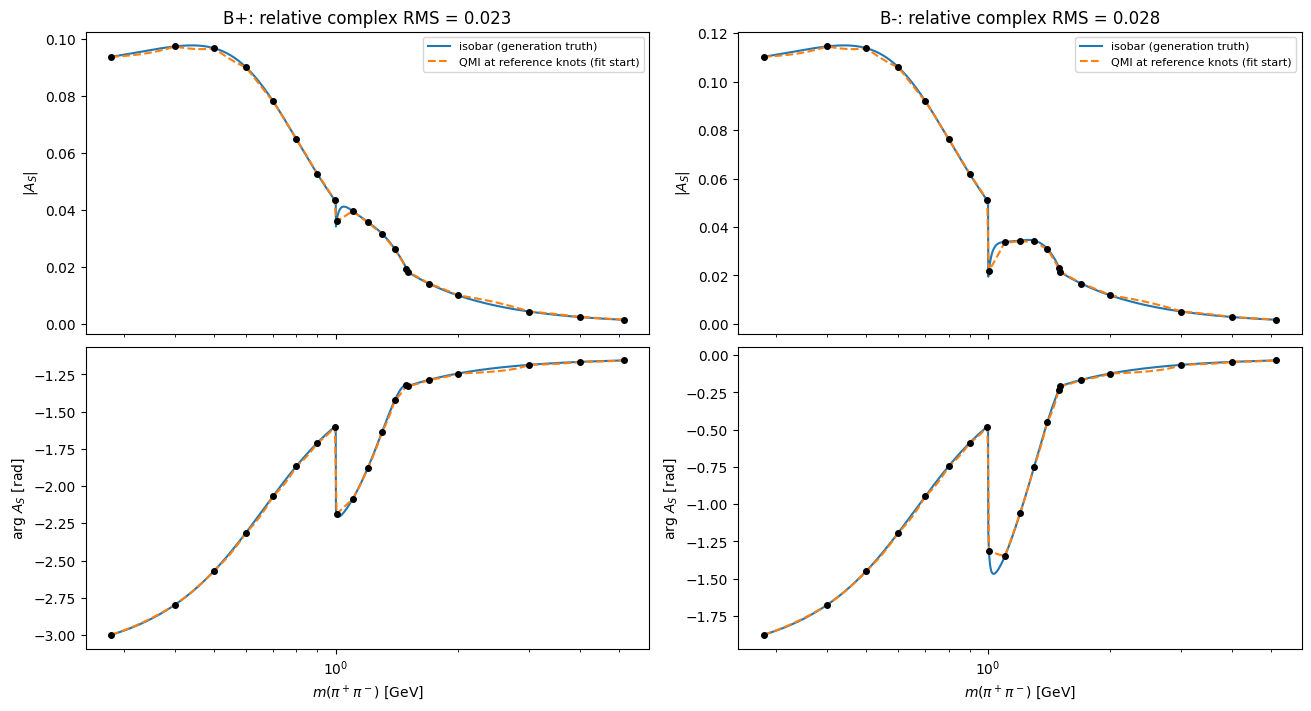

In [5]:
mass_scan = np.linspace(QMI_KNOTS[0], QMI_KNOTS[-1], 4000)
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, constrained_layout=True)
for column, (charge, model) in enumerate(((+1, plus_model), (-1, minus_model))):
    isobar = isobar_s_wave(charge, mass_scan)
    qmi_component = next(c for c in model.amplitude_model.components if c.name == "S_QMI")
    qmi_lineshape = resolve_value(qmi_component.function.lineshape, TRUE_VALUES)
    qmi = np.asarray(qmi_lineshape(jnp.asarray(mass_scan), qmi_component.function.context.resolve({})))
    relative_rms = np.sqrt(np.mean(np.abs(qmi - isobar) ** 2) / np.mean(np.abs(isobar) ** 2))
    label = "B+" if charge > 0 else "B-"

    axes[0, column].plot(mass_scan, np.abs(isobar), label="isobar (generation truth)")
    axes[0, column].plot(mass_scan, np.abs(qmi), "--", label="QMI at reference knots (fit start)")
    axes[0, column].plot(QMI_KNOTS, np.abs(S_WAVE_KNOTS[charge]), "o", ms=4, color="black")
    axes[0, column].set_title(f"{label}: relative complex RMS = {relative_rms:.3f}")
    axes[0, column].set_ylabel(r"$|A_S|$")
    axes[0, column].legend(fontsize=8)

    axes[1, column].plot(mass_scan, np.angle(isobar))
    axes[1, column].plot(mass_scan, np.angle(qmi), "--")
    axes[1, column].plot(QMI_KNOTS, np.angle(S_WAVE_KNOTS[charge]), "o", ms=4, color="black")
    axes[1, column].set_ylabel(r"arg $A_S$ [rad]")
    axes[1, column].set_xlabel(r"$m(\pi^+\pi^-)$ [GeV]")
    axes[1, column].set_xscale("log")
plt.show()

## Gen-fit loop

For each `iExpt`: generate one toy from the **isobar** model (accept-reject, deterministic seed),
fit it with the **QMI** model through `CPFitSession` starting from the reference values, and append
one row to `RESULTS_CSV` with the fit status, the value and HESSE error of every free parameter, and
the per-charge magnitude/phase of every S-wave knot with errors propagated from the HESSE
covariance. The toy itself is discarded. Toys already in `RESULTS_CSV` are skipped; a toy whose
generation or fit raises is reported and skipped without stopping the loop (it is retried on the
next run).

In [6]:
import gc

import jax


def release_toy_memory():
    """Free the host/device memory one toy leaves behind.

    Every toy builds a new CPFitSession and accept-reject density, i.e. new jitted closures.
    JAX keeps their traced programs and compiled executables in process-wide caches, so without
    this the kernel grows by ~80 MB per toy.
    """
    gc.collect()
    jax.clear_caches()
    gc.collect()


COMPILATION_CACHE_DIR = Path(os.environ["JAX_COMPILATION_CACHE_DIR"])
generator_programs_cached = False  # set once this kernel has kept the generator programs


def compilation_cache_entries():
    return set(COMPILATION_CACHE_DIR.iterdir()) if COMPILATION_CACHE_DIR.is_dir() else set()


def discard_new_cache_entries(kept):
    """Delete persistent-cache entries written since the snapshot `kept`.

    The fit programs (NLL/gradient, Hessian, prepared-cache kernels) embed the toy's events as
    constants, ~10 MB each, and the shuffle programs depend on the toy's B+/B- split, so no
    later toy or kernel can reuse them: without this the cache grows by ~20 MB per toy.
    """
    for entry in compilation_cache_entries() - kept:
        entry.unlink(missing_ok=True)


def toy_seed(iexpt):
    return int(np.random.SeedSequence([TOY_BASE_SEED, iexpt]).generate_state(1)[0])


def generate_toy(iexpt):
    return generate_cp_toy(
        ISOBAR_MODELS[+1], ISOBAR_MODELS[-1], N_TOY_EVENTS,
        parameters={},
        method="accept-reject",
        pool_size=TOY_POOL_SIZE,
        include_momenta=False,
        seed=toy_seed(iexpt),
    )


def s_wave_mag_phase(values, covariance, k, charge):
    """Magnitude/phase of A_S^q(m_k) = (x + q dx) + i(y + q dy) with propagated HESSE errors."""
    names = [f"S_QMI[{k}].{axis}" for axis in ("x", "y", "dx", "dy")]
    x, y, dx, dy = (values[name] for name in names)
    re, im = x + charge * dx, y + charge * dy
    mag = float(np.hypot(re, im))
    phase = float(np.arctan2(im, re))
    if covariance is None:
        return mag, phase, np.nan, np.nan
    cov = np.array([[covariance[a, b] for b in names] for a in names])
    d_re = np.array([1.0, 0.0, charge, 0.0])
    d_im = np.array([0.0, 1.0, 0.0, charge])
    j_mag = (re * d_re + im * d_im) / mag
    j_phase = (re * d_im - im * d_re) / mag**2
    return mag, phase, float(np.sqrt(j_mag @ cov @ j_mag)), float(np.sqrt(j_phase @ cov @ j_phase))


def run_toy(iexpt):
    global generator_programs_cached
    cache_snapshot = compilation_cache_entries()
    try:
        t0 = time.perf_counter()
        plus_data, minus_data = generate_toy(iexpt)
        gen_time = time.perf_counter() - t0
        if not generator_programs_cached:
            # Keep what the first toy of this kernel compiled for the generator: those programs
            # are the same for every toy and are what a restarted kernel reloads.
            cache_snapshot = compilation_cache_entries()
            generator_programs_cached = True

        session = CPFitSession(plus_model, minus_model, plus_data, minus_data)
        t0 = time.perf_counter()
        result = session.fit(
            dict(TRUE_VALUES), strategy=FIT_STRATEGY, ncall=FIT_NCALL,
            hesse=True, hessian="jax", verbose=0,
        )
        fit_time = time.perf_counter() - t0
    finally:
        discard_new_cache_entries(cache_snapshot)
    values = session.result_values(result)

    row = {
        "iExpt": iexpt,
        "seed": toy_seed(iexpt),
        "n_plus": plus_data.size,
        "n_minus": minus_data.size,
        "valid": bool(result.valid),
        "accurate_covariance": bool(result.fmin.has_accurate_covar),
        "nll": float(result.fval),
        "edm": float(result.fmin.edm),
        "nfcn": int(result.nfcn),
        "gen_time_s": gen_time,
        "fit_time_s": fit_time,
    }
    for name in FREE_PARAMETER_NAMES:
        row[name] = float(values[name])
        row[f"{name}_error"] = float(result.errors[name])
    covariance = result.covariance
    for charge in (+1, -1):
        for k in range(len(QMI_KNOTS)):
            mag, phase, mag_error, phase_error = s_wave_mag_phase(values, covariance, k, charge)
            row[s_wave_derived_name(k, "mag", charge)] = mag
            row[s_wave_derived_name(k, "mag", charge) + "_error"] = mag_error
            row[s_wave_derived_name(k, "phase", charge)] = phase
            row[s_wave_derived_name(k, "phase", charge) + "_error"] = phase_error
    return row


completed = (
    set(pd.read_csv(RESULTS_CSV)["iExpt"].astype(int)) if RESULTS_CSV.exists() else set()
)
pending = [i for i in TOY_INDICES if i not in completed]
print(f"{len(completed)} toys already fitted, {len(pending)} pending")

for iexpt in pending:
    try:
        row = run_toy(iexpt)
    except Exception as exc:  # keep the loop alive across a single bad toy
        print(f"iExpt={iexpt}: FAILED ({exc!r})")
        continue
    finally:
        release_toy_memory()
    pd.DataFrame([row]).to_csv(
        RESULTS_CSV, mode="a", header=not RESULTS_CSV.exists(), index=False
    )
    print(f"iExpt={iexpt}: valid={row['valid']} nll={row['nll']:.2f} "
          f"B+={row['n_plus']} B-={row['n_minus']} "
          f"(gen {row['gen_time_s']:.1f}s, fit {row['fit_time_s']:.1f}s)", flush=True)

254 toys already fitted, 246 pending
INFO Jax-PWA normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 1000 x 1000 grid.
INFO Jax-PWA normalization: automatic chunk size 1000000 of 1000000 points (84 B/point for AD; budget 2175 MiB, of which 195 MiB resident prepared blocks).
INFO Jax-PWA normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 1000 x 1000 grid.
INFO Jax-PWA normalization: automatic chunk size 1000000 of 1000000 points (84 B/point for AD; budget 2064 MiB, of which 195 MiB resident prepared blocks).
iExpt=254: valid=True nll=247970.70 B+=23777 B-=26223 (gen 9.2s, fit 74.1s)
iExpt=255: valid=True nll=246994.72 B+=23851 B-=26149 (gen 9.5s, fit 90.0s)
iExpt=256: valid=True nll=248016.70 B+=23671 B-=26329 (gen 9.8s, fit 89.4s)
iExpt=257: valid=True nll=248667.40 B+=23792 B-=26208 (gen 10.1s, fit 97.1s)
iExpt=258: valid

## Results: per-parameter distributions

`toy_results` collects every toy in `RESULTS_CSV`, including earlier runs of the loop. Only toys
with `valid=True` enter the pull statistics. For the QMI knots the "true value" is the
isobaric reference at the knot mass (see the introduction), so their pulls also measure the
knot-grid approximation.

In [7]:
toy_results = pd.read_csv(RESULTS_CSV)
n_valid = int(toy_results["valid"].sum())
print(f"{len(toy_results)} toys fitted, {n_valid} with valid=True")

toy_results_valid = toy_results[toy_results["valid"]].copy()
for name in FREE_PARAMETER_NAMES:
    toy_results_valid[f"{name}_pull"] = (
        toy_results_valid[name] - TRUE_VALUES[name]
    ) / toy_results_valid[f"{name}_error"]


def wrap_phase(delta):
    return np.angle(np.exp(1j * np.asarray(delta, dtype=float)))


derived_columns = {}
for name in DERIVED_NAMES:
    residual = toy_results_valid[name] - TRUE_DERIVED[name]
    if ".phase_" in name:
        residual = wrap_phase(residual)
    derived_columns[f"{name}_residual"] = residual
    derived_columns[f"{name}_pull"] = residual / toy_results_valid[f"{name}_error"]
toy_results_valid = pd.concat(
    [toy_results_valid, pd.DataFrame(derived_columns, index=toy_results_valid.index)], axis=1
)

500 toys fitted, 500 with valid=True




In [8]:
def _gaussian(x, amplitude, mu, sigma):
    return amplitude * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def histogram_bins(n):
    """Bin count that keeps bins populated for small ensembles (sqrt rule, 5..30 bins)."""
    return int(np.clip(np.sqrt(n), 5, 30))


def fit_gaussian(data, bins):
    """Unbinned Gaussian maximum-likelihood fit, i.e. the sample mean and standard deviation.

    Always defined (no minimizer that can fail on sparse histograms); the errors are the
    asymptotic ones, sigma/sqrt(n) for mu and sigma/sqrt(2(n-1)) for sigma. `amplitude` only
    scales the curve to the histogram drawn with `bins`.
    """
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    n = data.size
    mu = data.mean()
    sigma = data.std(ddof=1) if n > 1 else 0.0
    counts, edges = np.histogram(data, bins=bins)
    width = edges[1] - edges[0]
    amplitude = n * width / (np.sqrt(2.0 * np.pi) * sigma) if sigma > 0 else counts.max()
    return {
        "amplitude": amplitude, "mu": mu, "sigma": sigma,
        "mu_error": sigma / np.sqrt(n) if n > 0 else np.nan,
        "sigma_error": sigma / np.sqrt(2.0 * (n - 1)) if n > 1 else np.nan,
    }, edges


GAUSSIAN_FITS = {}

fig, axes = plt.subplots(len(FREE_PARAMETER_NAMES), 3,
                         figsize=(15.5, 3.1 * len(FREE_PARAMETER_NAMES)), constrained_layout=True)

for row, name in enumerate(FREE_PARAMETER_NAMES):
    values = toy_results_valid[name].to_numpy()
    errors_ = toy_results_valid[f"{name}_error"].to_numpy()
    pulls = toy_results_valid[f"{name}_pull"].to_numpy()
    true_value = TRUE_VALUES[name]

    n_bins = histogram_bins(len(values))
    value_fit, value_edges = fit_gaussian(values, bins=n_bins)
    error_fit, error_edges = fit_gaussian(errors_, bins=n_bins)
    pull_fit, pull_edges = fit_gaussian(pulls, bins=np.linspace(-5, 5, n_bins + 1))
    GAUSSIAN_FITS[name] = {"value": value_fit, "error": error_fit, "pull": pull_fit}

    ax_val, ax_err, ax_pull = axes[row]
    ax_val.hist(values, bins=value_edges, color="#4C72B0", edgecolor="white")
    x_val = np.linspace(value_edges[0], value_edges[-1], 300)
    ax_val.plot(x_val, _gaussian(x_val, value_fit["amplitude"], value_fit["mu"], value_fit["sigma"]),
                color="#DD8452")
    ax_val.axvline(true_value, color="black", linestyle="--", label="true value")
    ax_val.set_title(
        f"{name}  (n={len(values)})\n"
        fr"$\mu$={value_fit['mu']:.5g}$\pm${value_fit['mu_error']:.2g}  "
        fr"$\sigma$={value_fit['sigma']:.5g}$\pm${value_fit['sigma_error']:.2g}"
    )
    ax_val.set_xlabel("fitted value")
    if row == 0:
        ax_val.legend(fontsize=8)

    ax_err.hist(errors_, bins=error_edges, color="#8172B2", edgecolor="white")
    x_err = np.linspace(error_edges[0], error_edges[-1], 300)
    ax_err.plot(x_err, _gaussian(x_err, error_fit["amplitude"], error_fit["mu"], error_fit["sigma"]),
                color="#DD8452")
    ax_err.set_title(
        fr"HESSE error: $\mu$={error_fit['mu']:.3g}$\pm${error_fit['mu_error']:.2g}  "
        fr"$\sigma$={error_fit['sigma']:.3g}$\pm${error_fit['sigma_error']:.2g}"
    )
    ax_err.set_xlabel("parameter error (HESSE)")

    ax_pull.hist(pulls, bins=pull_edges, color="#55A868", edgecolor="white")
    x_pull = np.linspace(pull_edges[0], pull_edges[-1], 300)
    ax_pull.plot(x_pull, _gaussian(x_pull, pull_fit["amplitude"], pull_fit["mu"], pull_fit["sigma"]),
                 color="#C44E52")
    ax_pull.axvline(0.0, color="black", linestyle="--")
    ax_pull.set_title(
        fr"pull: $\mu$={pull_fit['mu']:.3f}$\pm${pull_fit['mu_error']:.3f}  "
        fr"$\sigma$={pull_fit['sigma']:.3f}$\pm${pull_fit['sigma_error']:.3f}"
    )
    ax_pull.set_xlabel("(fitted - true) / error")

## Numerical summary

For each free parameter: the true generation value and the unbinned Gaussian-fit parameters (sample mean and
standard deviation, with their asymptotic uncertainties) of the fitted-value, HESSE-error and pull distributions. An unbiased fit
with correct uncertainties gives `pull_mu` close to 0 and `pull_sigma` close to 1.

In [9]:
summary_rows = []
for name in FREE_PARAMETER_NAMES:
    row = {"parameter": name, "true_value": TRUE_VALUES[name]}
    for kind in ("value", "error", "pull"):
        fit = GAUSSIAN_FITS[name][kind]
        row.update({
            f"{kind}_mu": fit["mu"], f"{kind}_mu_error": fit["mu_error"],
            f"{kind}_sigma": fit["sigma"], f"{kind}_sigma_error": fit["sigma_error"],
        })
    summary_rows.append(row)

pull_summary = pd.DataFrame(summary_rows).set_index("parameter")
pull_summary.to_csv(RESULTS_CSV.with_name(RESULTS_CSV.stem + "_pull_summary.csv"))
pull_summary

,true_value,value_mu,value_mu_error,value_sigma,value_sigma_error,error_mu,error_mu_error,error_sigma,error_sigma_error,pull_mu,pull_mu_error,pull_sigma,pull_sigma_error
parameter,,,,,,,,,,,,,
rho770.dx,-0.003000,-0.001909,0.000470,0.010507,0.000333,0.009796,0.000037,0.000827,0.000026,0.087780,0.048666,1.088214,0.034447
omega782.x,0.091000,0.090854,0.000234,0.005232,0.000166,0.004989,0.000003,0.000067,0.000002,-0.036233,0.046871,1.048057,0.033176
omega782.y,-0.007000,-0.007226,0.000253,0.005659,0.000179,0.005609,0.000004,0.000081,0.000003,-0.040297,0.045144,1.009442,0.031953
omega782.dx,0.000000,0.000118,0.000205,0.004574,0.000145,0.004694,0.000002,0.000049,0.000002,0.025354,0.043610,0.975145,0.030868
omega782.dy,-0.022000,-0.022421,0.000232,0.005191,0.000164,0.005621,0.000004,0.000080,0.000003,-0.074673,0.041336,0.924296,0.029258
...,...,...,...,...,...,...,...,...,...,...,...,...,...
S_QMI[18].dy,-0.001057,-0.001007,0.000050,0.001119,0.000035,0.001069,0.000005,0.000110,0.000003,0.068702,0.048496,1.084406,0.034326
S_QMI[19].x,0.001159,0.001462,0.000095,0.002121,0.000067,0.002125,0.000006,0.000132,0.000004,0.119286,0.045102,1.008519,0.031924
S_QMI[19].y,-0.000702,-0.000190,0.000170,0.003798,0.000120,0.003768,0.000020,0.000449,0.000014,0.078397,0.045500,1.017408,0.032205


## S-wave recovery: magnitude and phase per knot and charge

Top: isobaric generation S-wave (line), reference values at the knots (black), and the toy-ensemble
mean of the fitted knots with the toy-to-toy spread (error bar = standard deviation over toys).
Bottom: pull mean ± pull width per knot (the band marks $|\mu| < 0.2$ and $\sigma = 1$). Phases are
compared modulo $2\pi$; a knot whose magnitude is compatible with zero has an ill-defined phase.

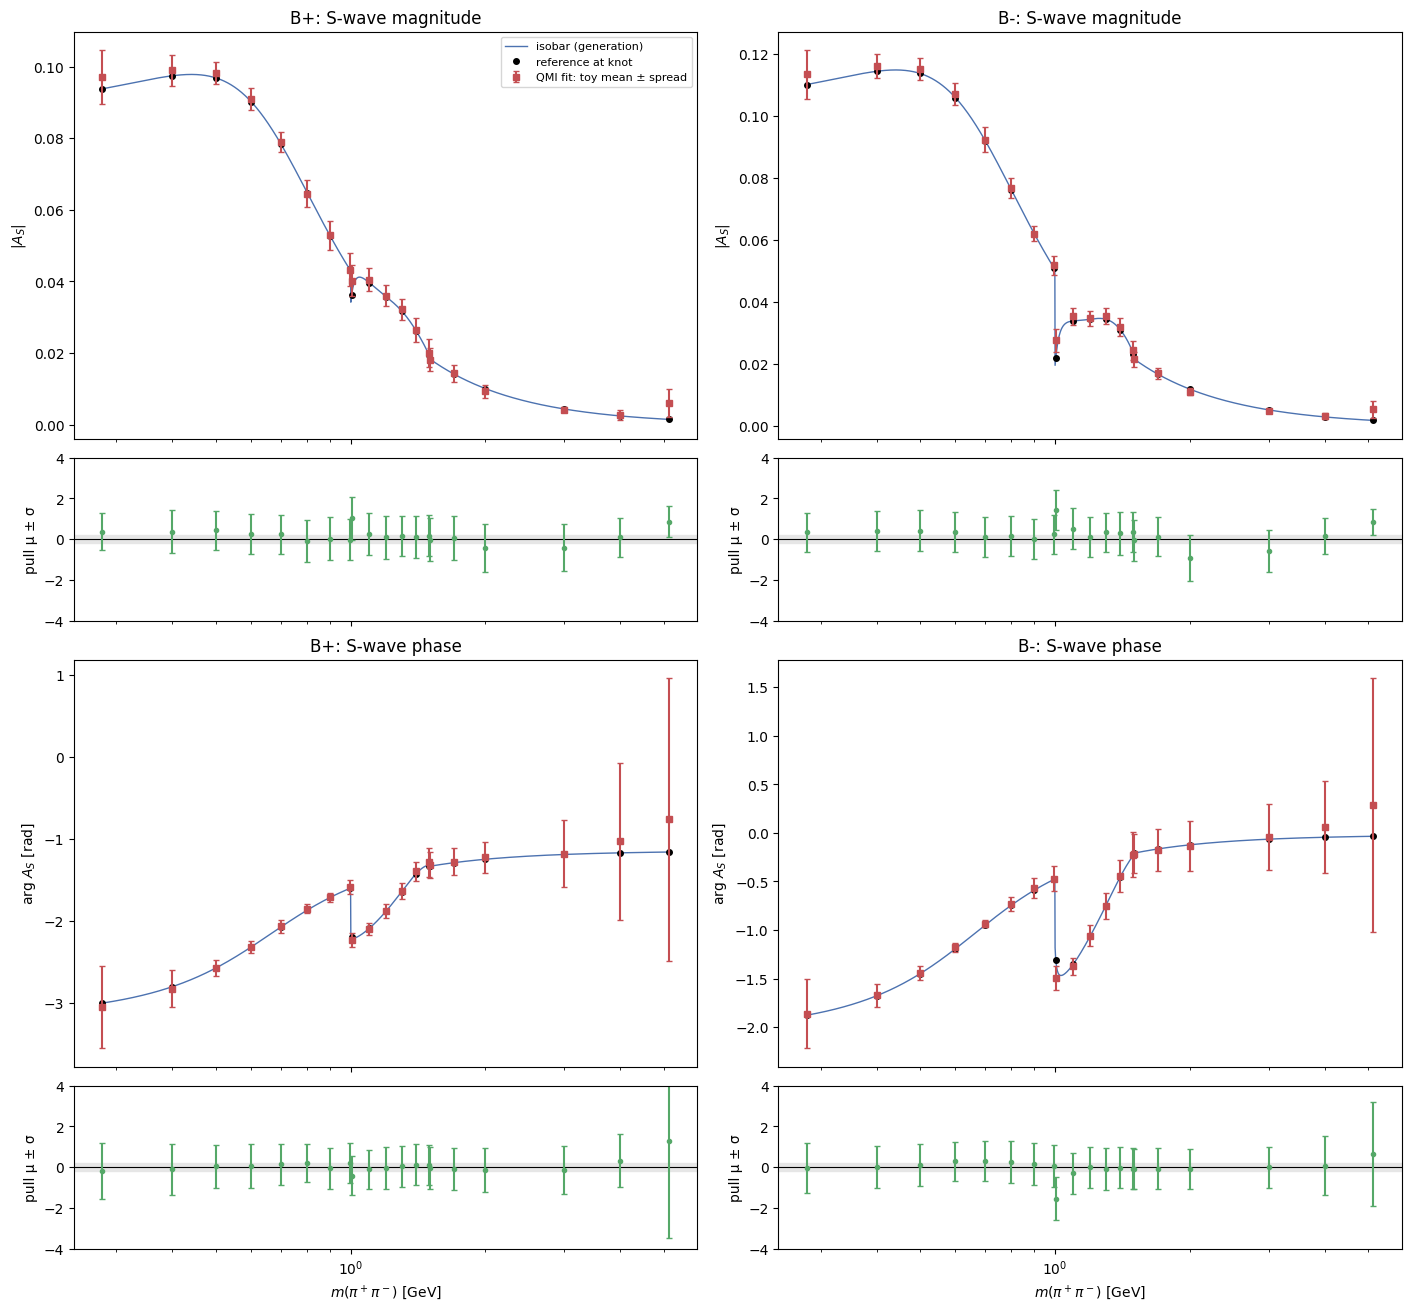

In [10]:
knot_masses = np.asarray(QMI_KNOTS)
mass_scan = np.linspace(QMI_KNOTS[0], QMI_KNOTS[-1], 4000)


def derived_stats(quantity, charge):
    names = [s_wave_derived_name(k, quantity, charge) for k in range(len(QMI_KNOTS))]
    truth = np.array([TRUE_DERIVED[n] for n in names])
    residuals = np.array([toy_results_valid[f"{n}_residual"].to_numpy() for n in names])
    pulls = np.array([toy_results_valid[f"{n}_pull"].to_numpy() for n in names])
    errors_ = np.array([toy_results_valid[f"{n}_error"].to_numpy() for n in names])
    # Mean fitted value as reference + mean residual: phase residuals are already wrapped, so
    # this stays next to the reference instead of jumping by 2 pi near +-pi.
    mean = truth + np.nanmean(residuals, axis=1)
    return {
        "names": names, "truth": truth, "mean": mean,
        "spread": np.nanstd(residuals, axis=1, ddof=1),
        "mean_error": np.nanmean(errors_, axis=1),
        "pull_mu": np.nanmean(pulls, axis=1), "pull_sigma": np.nanstd(pulls, axis=1, ddof=1),
    }


fig, axes = plt.subplots(4, 2, figsize=(14, 13), sharex=True, constrained_layout=True,
                         gridspec_kw={"height_ratios": [3, 1.2, 3, 1.2]})
for column, charge in enumerate((+1, -1)):
    label = "B+" if charge > 0 else "B-"
    isobar = isobar_s_wave(charge, mass_scan)
    for block, quantity in enumerate(("mag", "phase")):
        stats = derived_stats(quantity, charge)
        ax, ax_pull = axes[2 * block, column], axes[2 * block + 1, column]
        curve = np.abs(isobar) if quantity == "mag" else np.angle(isobar)
        ax.plot(mass_scan, curve, color="#4C72B0", lw=1, label="isobar (generation)")
        ax.plot(knot_masses, stats["truth"], "o", color="black", ms=4, label="reference at knot")
        ax.errorbar(knot_masses, stats["mean"], yerr=stats["spread"], fmt="s", ms=4,
                    color="#C44E52", capsize=2, label="QMI fit: toy mean ± spread")
        ax.set_ylabel(r"$|A_S|$" if quantity == "mag" else r"arg $A_S$ [rad]")
        ax.set_title(f"{label}: S-wave {'magnitude' if quantity == 'mag' else 'phase'}")
        if block == 0 and column == 0:
            ax.legend(fontsize=8)

        ax_pull.axhspan(-0.2, 0.2, color="0.9")
        ax_pull.axhline(0.0, color="black", lw=0.8)
        ax_pull.errorbar(knot_masses, stats["pull_mu"], yerr=stats["pull_sigma"], fmt="o", ms=3,
                         color="#55A868", capsize=2)
        ax_pull.set_ylabel("pull μ ± σ")
        ax_pull.set_ylim(-4, 4)
for ax in axes[-1]:
    ax.set_xscale("log")
    ax.set_xlabel(r"$m(\pi^+\pi^-)$ [GeV]")
plt.show()

### S-wave knot table

Per knot and charge: reference value, mean fitted value, bias in units of the toy spread, toy
spread vs. mean HESSE error, and the pull mean and width.

In [11]:
s_wave_rows = []
for charge in (+1, -1):
    for quantity in ("mag", "phase"):
        stats = derived_stats(quantity, charge)
        for k, mass in enumerate(QMI_KNOTS):
            s_wave_rows.append({
                "charge": "B+" if charge > 0 else "B-", "quantity": quantity, "knot": k,
                "m_GeV": mass, "reference": stats["truth"][k], "toy_mean": stats["mean"][k],
                "bias_over_spread": (stats["mean"][k] - stats["truth"][k]) / stats["spread"][k],
                "toy_spread": stats["spread"][k], "mean_hesse_error": stats["mean_error"][k],
                "pull_mu": stats["pull_mu"][k], "pull_sigma": stats["pull_sigma"][k],
            })
s_wave_summary = pd.DataFrame(s_wave_rows).set_index(["charge", "quantity", "knot"])
s_wave_summary.to_csv(RESULTS_CSV.with_name(RESULTS_CSV.stem + "_swave_summary.csv"))
s_wave_summary

m_GeV  reference  toy_mean  bias_over_spread  \
charge quantity knot                                                    
B+     mag      0     0.279141   0.093791  0.097134          0.448885   
                1     0.400000   0.097434  0.098939          0.353457   
                2     0.500000   0.096849  0.098297          0.463809   
                3     0.600000   0.090175  0.090945          0.253068   
                4     0.700000   0.078249  0.079029          0.280838   
...                        ...        ...       ...               ...   
B-     phase    15    1.700000  -0.164727 -0.173998         -0.042998   
                16    2.000000  -0.122743 -0.136687         -0.053833   
                17    3.000000  -0.064277 -0.043686          0.061090   
                18    4.000000  -0.044480  0.060750          0.223879   
                19    5.139840  -0.034578  0.289239          0.248191   

                      toy_spread  mean_hesse_error   pull_mu  pull_sigma  
charge quantity knot                                                      
B+     mag      0       0.007449          0.008048  0.358768    0.913398  
                1       0.004258          0.004013  0.369619    1.068230  
                2       0.003121          0.003269  0.433374    0.952438  
                3       0.003042          0.003066  0.243813    0.990079  
                4       0.002779          0.002893  0.245756    0.960436  
...                          ...               ...       ...         ...  
B-     phase    15      0.215618          0.223090 -0.069591    1.004712  
                16      0.259036          0.278415 -0.079601    0.981000  
                17      0.337049          0.346809 -0.013380    1.020875  
                18      0.470027          0.483425  0.076743    1.431983  
                19      1.304705          1.136660  0.639455    2.539180  

[80 rows x 8 columns]

## P/D/F-wave parameters

The P/D/F-wave coefficients have exact true values (Table XXI) in both models, so any bias here is
induced by describing the isobaric S-wave with the QMI.

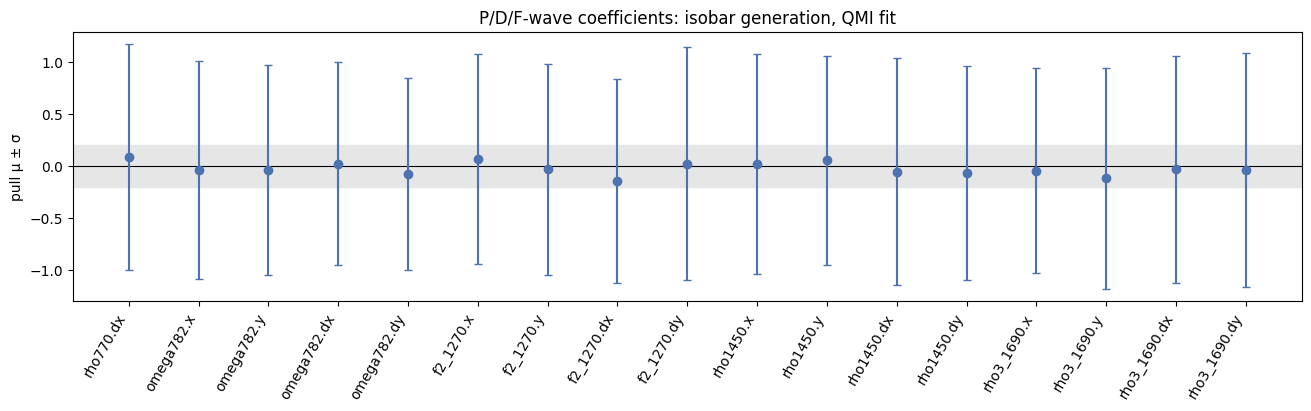

,true_value,value_mu,value_sigma,bias_over_spread,error_mu,pull_mu,pull_mu_error,pull_sigma,pull_sigma_error
parameter,,,,,,,,,
rho770.dx,-0.003,-0.001909,0.010507,0.103874,0.009796,0.087780,0.048666,1.088214,0.034447
omega782.x,0.091,0.090854,0.005232,-0.027907,0.004989,-0.036233,0.046871,1.048057,0.033176
omega782.y,-0.007,-0.007226,0.005659,-0.039917,0.005609,-0.040297,0.045144,1.009442,0.031953
omega782.dx,0.000,0.000118,0.004574,0.025712,0.004694,0.025354,0.043610,0.975145,0.030868
omega782.dy,-0.022,-0.022421,0.005191,-0.081091,0.005621,-0.074673,0.041336,0.924296,0.029258
f2_1270.x,0.291,0.291902,0.012743,0.070767,0.012840,0.070214,0.044972,1.005600,0.031832
f2_1270.y,0.204,0.203479,0.013062,-0.039897,0.012897,-0.027915,0.045365,1.014395,0.032110
f2_1270.dx,-0.002,-0.003513,0.010825,-0.139783,0.011283,-0.142991,0.043699,0.977133,0.030931
f2_1270.dy,-0.179,-0.177928,0.015873,0.067533,0.014598,0.023982,0.049990,1.117821,0.035384


In [12]:
pdf_wave_summary = pull_summary.loc[PDF_WAVE_PARAMETER_NAMES].copy()
pdf_wave_summary["bias_over_spread"] = (
    (pdf_wave_summary["value_mu"] - pdf_wave_summary["true_value"]) / pdf_wave_summary["value_sigma"]
)
pdf_wave_summary = pdf_wave_summary[[
    "true_value", "value_mu", "value_sigma", "bias_over_spread", "error_mu",
    "pull_mu", "pull_mu_error", "pull_sigma", "pull_sigma_error",
]]

fig, ax = plt.subplots(figsize=(13, 4), constrained_layout=True)
positions = np.arange(len(pdf_wave_summary))
ax.axhspan(-0.2, 0.2, color="0.9")
ax.axhline(0.0, color="black", lw=0.8)
ax.errorbar(positions, pdf_wave_summary["pull_mu"], yerr=pdf_wave_summary["pull_sigma"],
            fmt="o", color="#4C72B0", capsize=3)
ax.set_xticks(positions, pdf_wave_summary.index, rotation=60, ha="right")
ax.set_ylabel("pull μ ± σ")
ax.set_title("P/D/F-wave coefficients: isobar generation, QMI fit")
plt.show()

pdf_wave_summary